# Clustering B2B por dos capas

Este notebook implementa el analisis completo de clustering para la tesis usando las matrices finales ya procesadas en `03_feature_engineering/outputs`.

- `Capa 1`: modelo principal basado en features SRI de cobertura amplia.
- `Capa 2`: analisis de robustez sobre el subconjunto con informacion financiera SCVS.
- `es_cliente_fpa` se usa solo como validacion externa y nunca entra al modelo.
- El label `es_cliente_fpa` nace exclusivamente de registros de proyectos/horas FPA; los prospectos del CRM no se tratan como clientes.

Nota metodologica: este notebook toma como fuente de verdad los artefactos actuales generados desde el Golden Record manual. Los tamanos de muestra se calculan dinamicamente desde los CSV de `03_feature_engineering/outputs`.


In [1]:
# Celda 0 - Imports y rutas
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from scipy.cluster.hierarchy import linkage, dendrogram

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")

ROOT = Path("e:/TESIS MAESTRIA/Desarrollo_clustering_maestria")

PATH_FEAT_C1 = ROOT / "03_feature_engineering/outputs/features_capa1.csv"
PATH_FEAT_C2 = ROOT / "03_feature_engineering/outputs/features_capa2.csv"
PATH_MAT_C1 = ROOT / "03_feature_engineering/outputs/matriz_capa1.csv"
PATH_MAT_C2 = ROOT / "03_feature_engineering/outputs/matriz_capa2.csv"
PATH_LAB_C1 = ROOT / "03_feature_engineering/outputs/labels_capa1.csv"
PATH_LAB_C2 = ROOT / "03_feature_engineering/outputs/labels_capa2.csv"
PATH_OUT = ROOT / "04_modeling/outputs"
PATH_OUT.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
K_RANGE = list(range(2, 9))

print(f"ROOT: {ROOT}")
print(f"Output dir: {PATH_OUT}")


ROOT: e:\TESIS MAESTRIA\Desarrollo_clustering_maestria
Output dir: e:\TESIS MAESTRIA\Desarrollo_clustering_maestria\04_modeling\outputs


## 1. Carga de datos y control de calidad

Las matrices ya llegan escaladas y codificadas desde `03_matriz_final.ipynb`. En esta seccion solo verificamos consistencia, cobertura y trazabilidad entre matrices, labels y features crudas.


In [2]:
features_c1 = pd.read_csv(PATH_FEAT_C1, dtype={"RUC": str})
features_c2 = pd.read_csv(PATH_FEAT_C2, dtype={"RUC": str})
matriz_c1 = pd.read_csv(PATH_MAT_C1)
matriz_c2 = pd.read_csv(PATH_MAT_C2)
labels_c1 = pd.read_csv(PATH_LAB_C1, dtype={"RUC": str})
labels_c2 = pd.read_csv(PATH_LAB_C2, dtype={"RUC": str})

assert len(features_c1) == len(matriz_c1) == len(labels_c1), "Desalineacion en capa 1"
assert len(features_c2) == len(matriz_c2) == len(labels_c2), "Desalineacion en capa 2"
assert features_c1["RUC"].equals(labels_c1["RUC"]), "RUC no alineado en capa 1"
assert features_c2["RUC"].equals(labels_c2["RUC"]), "RUC no alineado en capa 2"
assert matriz_c1.isna().sum().sum() == 0, "NaN en matriz_capa1"
assert matriz_c2.isna().sum().sum() == 0, "NaN en matriz_capa2"

resumen_capas = pd.DataFrame(
    [
        {
            "capa": "Capa 1",
            "n_documentado": len(matriz_c1),
            "n_csv_actual": len(matriz_c1),
            "n_features_modelo": matriz_c1.shape[1],
            "clientes_fpa": int(labels_c1["es_cliente_fpa"].sum()),
            "ruc_unicos": labels_c1["RUC"].nunique(),
            "nulos_matriz": int(matriz_c1.isna().sum().sum()),
        },
        {
            "capa": "Capa 2",
            "n_documentado": len(matriz_c2),
            "n_csv_actual": len(matriz_c2),
            "n_features_modelo": matriz_c2.shape[1],
            "clientes_fpa": int(labels_c2["es_cliente_fpa"].sum()),
            "ruc_unicos": labels_c2["RUC"].nunique(),
            "nulos_matriz": int(matriz_c2.isna().sum().sum()),
        },
    ]
)

display(resumen_capas)


,capa,n_documentado,n_csv_actual,n_features_modelo,clientes_fpa,ruc_unicos,nulos_matriz
0,Capa 1,181,181,14,82,181,0
1,Capa 2,141,141,20,57,141,0


In [3]:
resumen_columnas = pd.DataFrame(
    {
        "matriz_capa1": pd.Series(matriz_c1.columns),
        "matriz_capa2": pd.Series(matriz_c2.columns),
    }
)

validaciones = pd.DataFrame(
    [
        {
            "check": "Duplicados RUC capa1",
            "valor": int(labels_c1["RUC"].duplicated().sum()),
        },
        {
            "check": "Duplicados RUC capa2",
            "valor": int(labels_c2["RUC"].duplicated().sum()),
        },
        {
            "check": "Clientes FPA capa1",
            "valor": int(labels_c1["es_cliente_fpa"].sum()),
        },
        {
            "check": "Clientes FPA capa2",
            "valor": int(labels_c2["es_cliente_fpa"].sum()),
        },
    ]
)

display(validaciones)
display(resumen_columnas)


,check,valor
0,Duplicados RUC capa1,0
1,Duplicados RUC capa2,0
2,Clientes FPA capa1,82
3,Clientes FPA capa2,57


,matriz_capa1,matriz_capa2
0,tipo_sociedad,tipo_sociedad
1,obligado_contabilidad,obligado_contabilidad
2,es_agente_retencion,es_agente_retencion
3,es_contribuyente_especial,es_contribuyente_especial
4,estado_activo,estado_activo
5,antiguedad_anos,antiguedad_anos
6,sector_ciiu_macro_C,log_empleados
7,sector_ciiu_macro_G,log_ingresos
8,sector_ciiu_macro_K,log_activos
9,sector_ciiu_macro_M,segmento


In [4]:
# ── Corrección: deduplicar Capa 1 por RUC antes de modelar ───────────────────
# Causa: la misma empresa aparece en la fuente HORAS y también en LEADS.
# Las features SRI son idénticas (mismo RUC → mismo registro SRI).
# Regla: si alguna fila del RUC tiene es_cliente_fpa=1, el RUC se marca como 1.

dups_ruc = labels_c1[labels_c1["RUC"].duplicated(keep=False)][
    ["name_norm", "RUC", "source_label", "es_cliente_fpa"]
].sort_values("RUC")
print(f"RUCs duplicados antes de corregir: {dups_ruc['RUC'].nunique()} únicos en {len(dups_ruc)} filas")
print(dups_ruc.to_string(index=False))
print()

# Ordenar: primero los que son clientes FPA (=1), luego los que no (=0)
# → drop_duplicates 'first' conserva el de mayor es_cliente_fpa
idx_ok = (
    labels_c1
    .sort_values("es_cliente_fpa", ascending=False)
    .drop_duplicates(subset="RUC", keep="first")
    .index
)

features_c1 = features_c1.loc[idx_ok].reset_index(drop=True)
matriz_c1   = matriz_c1.loc[idx_ok].reset_index(drop=True)
labels_c1   = labels_c1.loc[idx_ok].reset_index(drop=True)

print(f"Capa 1 corregida: {len(features_c1)} empresas | {labels_c1['RUC'].nunique()} RUCs únicos")
print(f"Clientes FPA: {int(labels_c1['es_cliente_fpa'].sum())}")
assert labels_c1["RUC"].duplicated().sum() == 0
assert len(features_c1) == len(matriz_c1) == len(labels_c1)

RUCs duplicados antes de corregir: 0 únicos en 0 filas
Empty DataFrame
Columns: [name_norm, RUC, source_label, es_cliente_fpa]
Index: []

Capa 1 corregida: 181 empresas | 181 RUCs únicos
Clientes FPA: 82


## 2. Funciones auxiliares

Se definen utilidades para:

1. visualizar el dendrograma de Ward,
2. evaluar candidatos de `K` con K-Means y clustering jerarquico,
3. construir perfiles de negocio por cluster,
4. exportar artefactos finales.


In [5]:
def plot_ward_dendrogram(X, title, figsize=(14, 5)):
    Z = linkage(X, method="ward")
    plt.figure(figsize=figsize)
    dendrogram(Z, no_labels=True, color_threshold=None)
    plt.title(title)
    plt.xlabel("Observaciones")
    plt.ylabel("Distancia Ward")
    plt.tight_layout()
    plt.show()
    return Z


def evaluate_kmeans_grid(X, k_values, random_state=RANDOM_STATE, n_init=25):
    rows = []
    for k in k_values:
        model = KMeans(n_clusters=k, random_state=random_state, n_init=n_init)
        labels = model.fit_predict(X)
        counts = pd.Series(labels).value_counts()
        rows.append(
            {
                "k": k,
                "inertia": model.inertia_,
                "silhouette": silhouette_score(X, labels),
                "davies_bouldin": davies_bouldin_score(X, labels),
                "min_cluster_size": int(counts.min()),
                "max_cluster_size": int(counts.max()),
            }
        )
    return pd.DataFrame(rows)


def evaluate_ward_grid(X, k_values):
    rows = []
    for k in k_values:
        labels = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(X)
        counts = pd.Series(labels).value_counts()
        rows.append(
            {
                "k": k,
                "silhouette": silhouette_score(X, labels),
                "davies_bouldin": davies_bouldin_score(X, labels),
                "min_cluster_size": int(counts.min()),
                "max_cluster_size": int(counts.max()),
            }
        )
    return pd.DataFrame(rows)


def plot_kmeans_diagnostics(metrics_df, title, chosen_k=None):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    sns.lineplot(data=metrics_df, x="k", y="inertia", marker="o", ax=axes[0], color="#1f77b4")
    axes[0].set_title(f"{title} - Elbow")
    axes[0].set_ylabel("Inertia (WCSS)")

    sns.lineplot(data=metrics_df, x="k", y="silhouette", marker="o", ax=axes[1], color="#2ca02c")
    axes[1].set_title(f"{title} - Silhouette")
    axes[1].set_ylabel("Silhouette")

    sns.lineplot(data=metrics_df, x="k", y="davies_bouldin", marker="o", ax=axes[2], color="#d62728")
    axes[2].set_title(f"{title} - Davies-Bouldin")
    axes[2].set_ylabel("Davies-Bouldin")

    if chosen_k is not None:
        for ax in axes:
            ax.axvline(chosen_k, color="black", linestyle="--", alpha=0.7)

    for ax in axes:
        ax.set_xticks(metrics_df["k"])

    plt.tight_layout()
    plt.show()


def top_category(series):
    moda = series.mode(dropna=True)
    if len(moda) == 0:
        return np.nan
    return moda.iloc[0]


def summarize_clusters(raw_df, cluster_col, continuous_cols, binary_cols, categorical_cols):
    summary = raw_df.groupby(cluster_col).size().rename("n").to_frame()
    summary["tasa_clientes_fpa"] = raw_df.groupby(cluster_col)["es_cliente_fpa"].mean()

    for col in continuous_cols:
        summary[f"mediana_{col}"] = raw_df.groupby(cluster_col)[col].median()

    for col in binary_cols:
        summary[f"prop_{col}"] = raw_df.groupby(cluster_col)[col].mean()

    for col in categorical_cols:
        summary[f"moda_{col}"] = raw_df.groupby(cluster_col)[col].agg(top_category)

    return summary.reset_index()


def plot_centroid_heatmap(centroids_df, title):
    plt.figure(figsize=(16, max(4, 1.1 * len(centroids_df))))
    sns.heatmap(centroids_df, cmap="coolwarm", center=0, annot=True, fmt=".2f")
    plt.title(title)
    plt.xlabel("Features escaladas")
    plt.ylabel("Clusters")
    plt.tight_layout()
    plt.show()


def plot_cluster_validation(summary_df, cluster_col, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.barplot(data=summary_df, x=cluster_col, y="n", ax=axes[0], color="#4C78A8")
    axes[0].set_title(f"{title} - Tamano")
    axes[0].set_ylabel("Empresas")

    sns.barplot(data=summary_df, x=cluster_col, y="tasa_clientes_fpa", ax=axes[1], color="#F58518")
    axes[1].set_title(f"{title} - Tasa clientes FPA")
    axes[1].set_ylabel("Proporcion")
    axes[1].set_ylim(0, max(0.5, summary_df["tasa_clientes_fpa"].max() + 0.05))

    plt.tight_layout()
    plt.show()


## 3. Exploracion jerarquica inicial

Ward se usa como herramienta exploratoria para identificar cortes plausibles antes de fijar `K` con K-Means.


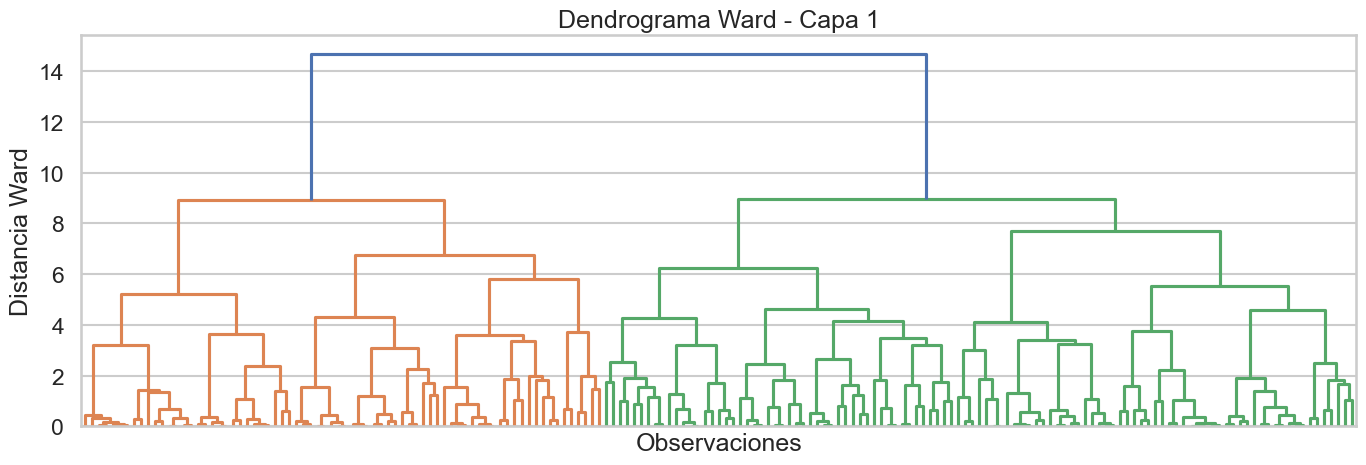

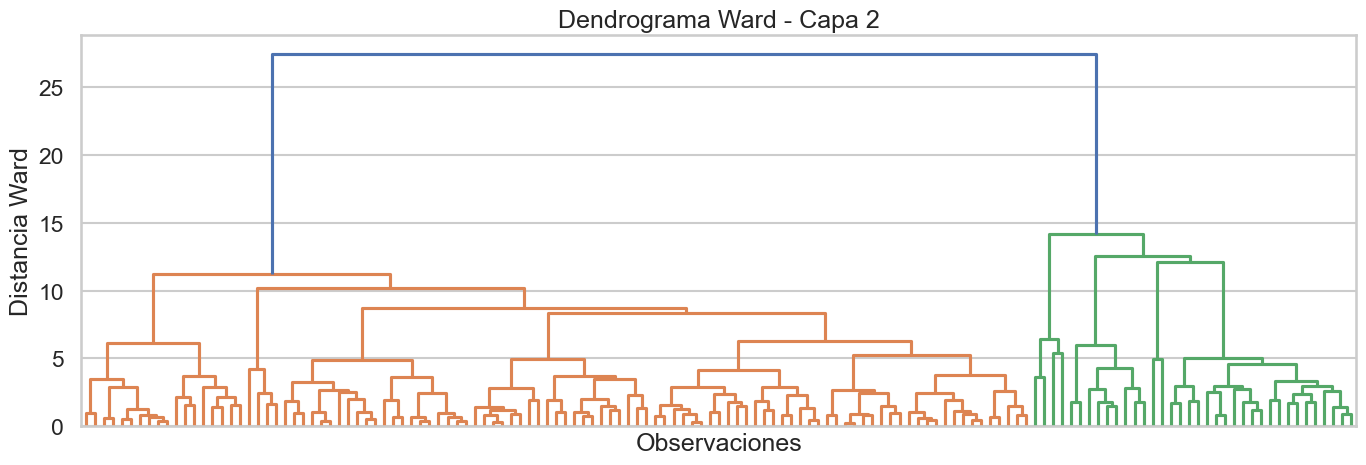

Ultimas 10 distancias de fusion - Capa 1: [ 4.646  5.232  5.552  5.793  6.228  6.772  7.719  8.909  8.969 14.677]
Ultimas 10 distancias de fusion - Capa 2: [ 6.258  6.463  8.344  8.699 10.158 11.206 12.112 12.519 14.145 27.403]


In [6]:
Z_c1 = plot_ward_dendrogram(matriz_c1, "Dendrograma Ward - Capa 1")
Z_c2 = plot_ward_dendrogram(matriz_c2, "Dendrograma Ward - Capa 2")

print("Ultimas 10 distancias de fusion - Capa 1:", np.round(Z_c1[-10:, 2], 3))
print("Ultimas 10 distancias de fusion - Capa 2:", np.round(Z_c2[-10:, 2], 3))


## 4. Seleccion de K

La decision combina:

- `Elbow` sobre inercia,
- `Silhouette`,
- `Davies-Bouldin`,
- tamano minimo de cluster para evitar segmentos espurios.


In [7]:
metricas_kmeans_c1 = evaluate_kmeans_grid(matriz_c1, K_RANGE)
metricas_kmeans_c2 = evaluate_kmeans_grid(matriz_c2, K_RANGE)
metricas_ward_c1 = evaluate_ward_grid(matriz_c1, range(2, 7))
metricas_ward_c2 = evaluate_ward_grid(matriz_c2, range(2, 7))

display(metricas_kmeans_c1.round(3))
display(metricas_ward_c1.round(3))
display(metricas_kmeans_c2.round(3))
display(metricas_ward_c2.round(3))


  File "C:\Users\asus\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,k,inertia,silhouette,davies_bouldin,min_cluster_size,max_cluster_size
0,2,380.683,0.224,1.590,66,115
1,3,329.789,0.192,1.838,56,64
2,4,295.682,0.209,1.601,35,60
3,5,267.000,0.215,1.453,27,44
4,6,250.692,0.208,1.529,17,43
5,7,233.972,0.213,1.469,11,39
6,8,221.393,0.192,1.591,10,29


,k,silhouette,davies_bouldin,min_cluster_size,max_cluster_size
0,2,0.176,1.871,74,107
1,3,0.139,2.111,50,74
2,4,0.138,1.908,30,57
3,5,0.166,1.698,23,50
4,6,0.180,1.684,21,50


,k,inertia,silhouette,davies_bouldin,min_cluster_size,max_cluster_size
0,2,837.879,0.379,1.212,31,110
1,3,720.268,0.197,1.605,17,71
2,4,620.537,0.209,1.341,3,71
3,5,549.378,0.233,1.141,2,84
4,6,500.288,0.172,1.299,2,70
5,7,452.113,0.182,1.241,2,53
6,8,414.206,0.178,1.240,2,42


,k,silhouette,davies_bouldin,min_cluster_size,max_cluster_size
0,2,0.370,1.323,36,105
1,3,0.364,1.184,4,105
2,4,0.297,1.263,4,105
3,5,0.267,1.058,2,105
4,6,0.162,1.236,2,87


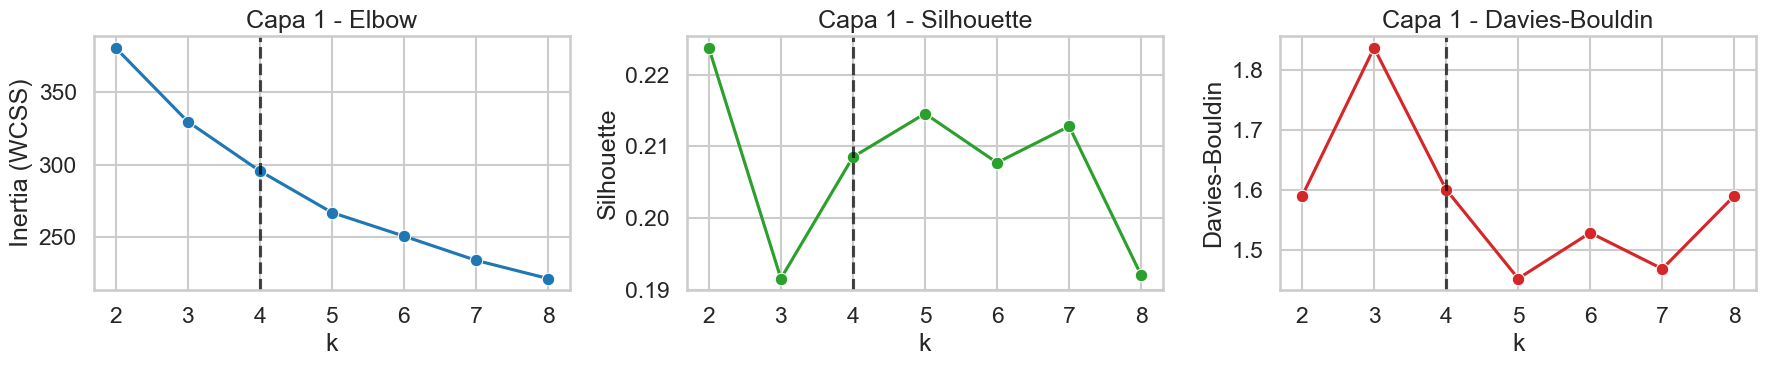

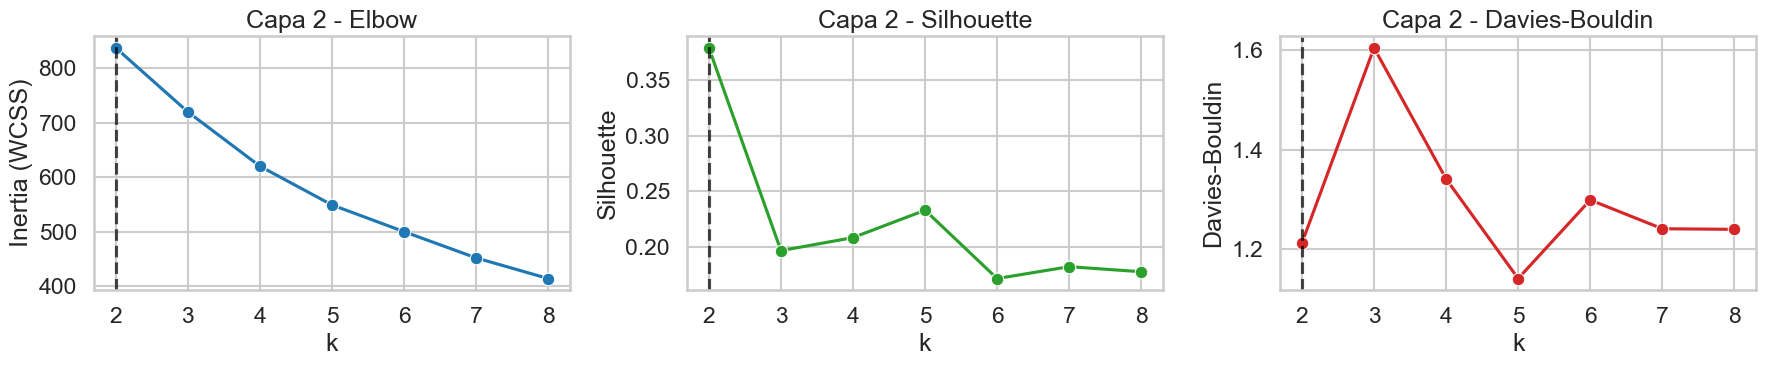

In [8]:
plot_kmeans_diagnostics(metricas_kmeans_c1, "Capa 1", chosen_k=4)
plot_kmeans_diagnostics(metricas_kmeans_c2, "Capa 2", chosen_k=2)


In [9]:
K_CAPA1 = 4
K_CAPA2 = 2
K_CAPA2_SENSIBILIDAD = 4

print("Decision final de K")
print("- Capa 1: K=4 -> mejor equilibrio entre interpretabilidad, tamanos balanceados y valor de negocio.")
print("- Capa 2: K=2 -> evita clusters de 1-2 empresas que aparecen desde K>=3 por outliers financieros.")
print("- Sensibilidad adicional: tambien se corre Capa 2 con K=4 para comparar contra el mismo K del modelo principal.")


Decision final de K
- Capa 1: K=4 -> mejor equilibrio entre interpretabilidad, tamanos balanceados y valor de negocio.
- Capa 2: K=2 -> evita clusters de 1-2 empresas que aparecen desde K>=3 por outliers financieros.
- Sensibilidad adicional: tambien se corre Capa 2 con K=4 para comparar contra el mismo K del modelo principal.


## 5. Modelo principal - Capa 1

Se ajusta K-Means con `K=4` sobre la matriz SRI, y luego se interpretan los clusters usando las features crudas para no perder semantica de negocio.


In [10]:
modelo_c1 = KMeans(n_clusters=K_CAPA1, random_state=RANDOM_STATE, n_init=25)
clusters_c1 = modelo_c1.fit_predict(matriz_c1)

segmentos_c1 = {
    0: "Comercio formal maduro en Pichincha",
    1: "Industriales consolidados de alta afinidad FPA",
    2: "Comercio formal emergente en Pichincha",
    3: "Comercio formal regional en Guayas",
}

asignaciones_c1 = labels_c1.copy()
asignaciones_c1["cluster_capa1"] = clusters_c1
asignaciones_c1["segmento_capa1"] = asignaciones_c1["cluster_capa1"].map(segmentos_c1)

perfil_raw_c1 = features_c1.copy()
perfil_raw_c1["cluster_capa1"] = clusters_c1
perfil_raw_c1["segmento_capa1"] = perfil_raw_c1["cluster_capa1"].map(segmentos_c1)

resumen_c1 = summarize_clusters(
    raw_df=perfil_raw_c1,
    cluster_col="cluster_capa1",
    continuous_cols=["antiguedad_anos"],
    binary_cols=[
        "tipo_sociedad",
        "obligado_contabilidad",
        "es_agente_retencion",
        "es_contribuyente_especial",
        "estado_activo",
    ],
    categorical_cols=["sector_ciiu_macro", "region", "source_label"],
)
resumen_c1["segmento_capa1"] = resumen_c1["cluster_capa1"].map(segmentos_c1)
resumen_c1 = resumen_c1[
    [
        "cluster_capa1",
        "segmento_capa1",
        "n",
        "tasa_clientes_fpa",
        "mediana_antiguedad_anos",
        "prop_tipo_sociedad",
        "prop_obligado_contabilidad",
        "prop_es_agente_retencion",
        "prop_es_contribuyente_especial",
        "prop_estado_activo",
        "moda_sector_ciiu_macro",
        "moda_region",
        "moda_source_label",
    ]
].sort_values("cluster_capa1")

display(resumen_c1.round(3))


,cluster_capa1,segmento_capa1,n,tasa_clientes_fpa,mediana_antiguedad_anos,prop_tipo_sociedad,prop_obligado_contabilidad,prop_es_agente_retencion,prop_es_contribuyente_especial,prop_estado_activo,moda_sector_ciiu_macro,moda_region,moda_source_label
0,0,Comercio formal maduro en Pichincha,46,0.435,56.5,1.0,1.0,0.891,0.957,0.957,G,Pichincha,LEADS
1,1,Industriales consolidados de alta afinidad FPA,35,0.657,33.0,1.0,1.0,0.943,1.000,0.971,C,Resto,HORAS
2,2,Comercio formal emergente en Pichincha,60,0.383,20.5,1.0,1.0,0.583,0.467,0.850,G,Pichincha,LEADS
3,3,Comercio formal regional en Guayas,40,0.400,26.0,1.0,1.0,0.825,0.750,0.850,G,Guayas,LEADS


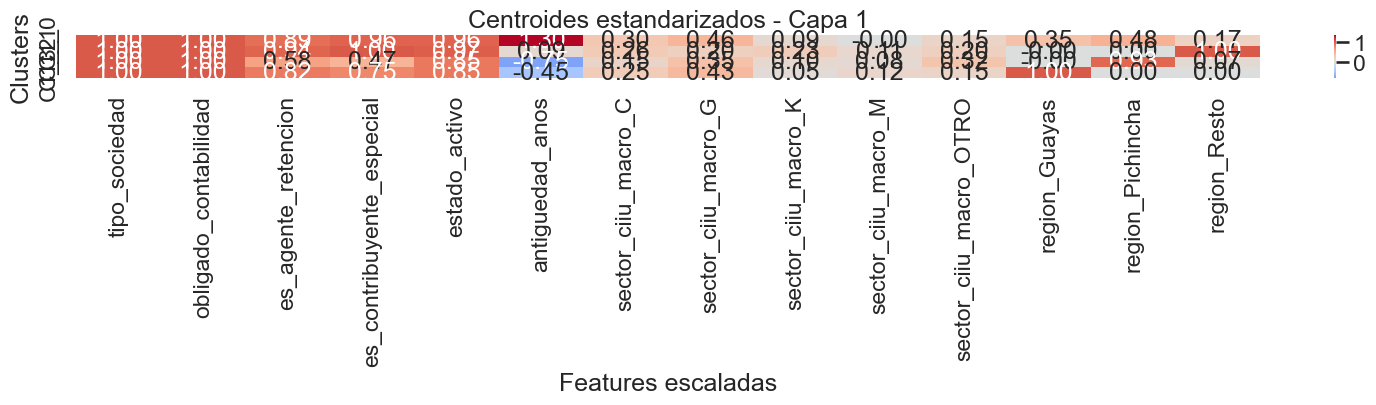

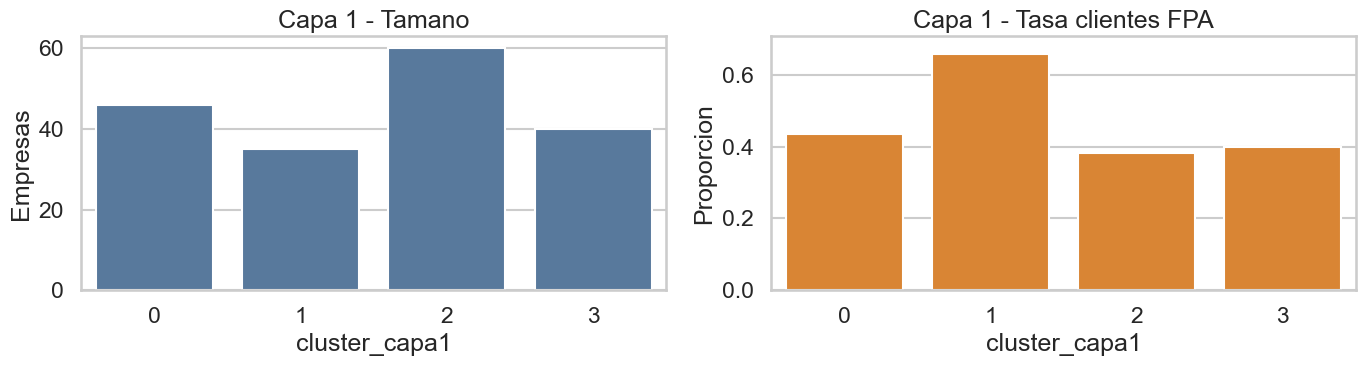

In [11]:
centroides_c1 = pd.DataFrame(modelo_c1.cluster_centers_, columns=matriz_c1.columns)
centroides_c1.index = [f"C1_{cluster}" for cluster in range(K_CAPA1)]
plot_centroid_heatmap(centroides_c1, "Centroides estandarizados - Capa 1")
plot_cluster_validation(resumen_c1, "cluster_capa1", "Capa 1")


## 6. Modelo de robustez - Capa 2

Primero se ajusta la solucion estable (`K=2`). Luego se ejecuta una corrida de sensibilidad con `K=4` para mostrar como los outliers financieros fragmentan artificialmente la muestra.


In [12]:
modelo_c2 = KMeans(n_clusters=K_CAPA2, random_state=RANDOM_STATE, n_init=25)
clusters_c2 = modelo_c2.fit_predict(matriz_c2)

segmentos_c2 = {
    0: "Empresas grandes consolidadas",
    1: "Empresas medianas y recientes de alta afinidad",
}

asignaciones_c2 = labels_c2.copy()
asignaciones_c2["cluster_capa2"] = clusters_c2
asignaciones_c2["segmento_capa2"] = asignaciones_c2["cluster_capa2"].map(segmentos_c2)

perfil_raw_c2 = features_c2.copy()
perfil_raw_c2["cluster_capa2"] = clusters_c2
perfil_raw_c2["segmento_capa2"] = perfil_raw_c2["cluster_capa2"].map(segmentos_c2)

resumen_c2 = summarize_clusters(
    raw_df=perfil_raw_c2,
    cluster_col="cluster_capa2",
    continuous_cols=[
        "antiguedad_anos",
        "log_empleados",
        "log_ingresos",
        "log_activos",
        "segmento",
        "liquidez_corriente",
        "margen_operacional",
    ],
    binary_cols=[
        "tipo_sociedad",
        "obligado_contabilidad",
        "es_agente_retencion",
        "es_contribuyente_especial",
        "estado_activo",
    ],
    categorical_cols=["sector_ciiu_macro", "region", "source_label"],
)
resumen_c2["segmento_capa2"] = resumen_c2["cluster_capa2"].map(segmentos_c2)
resumen_c2 = resumen_c2.sort_values("cluster_capa2")

display(resumen_c2.round(3))


,cluster_capa2,n,tasa_clientes_fpa,mediana_antiguedad_anos,mediana_log_empleados,mediana_log_ingresos,mediana_log_activos,mediana_segmento,mediana_liquidez_corriente,mediana_margen_operacional,prop_tipo_sociedad,prop_obligado_contabilidad,prop_es_agente_retencion,prop_es_contribuyente_especial,prop_estado_activo,moda_sector_ciiu_macro,moda_region,moda_source_label,segmento_capa2
0,0,110,0.391,33.0,2.208,7.62,7.575,4.0,1.48,-4.86,1.0,1.0,0.918,0.964,0.991,G,Pichincha,LEADS,Empresas grandes consolidadas
1,1,31,0.452,13.0,0.699,5.21,5.870,2.0,1.27,0.00,1.0,1.0,0.581,0.129,1.000,OTRO,Pichincha,LEADS,Empresas medianas y recientes de alta afinidad


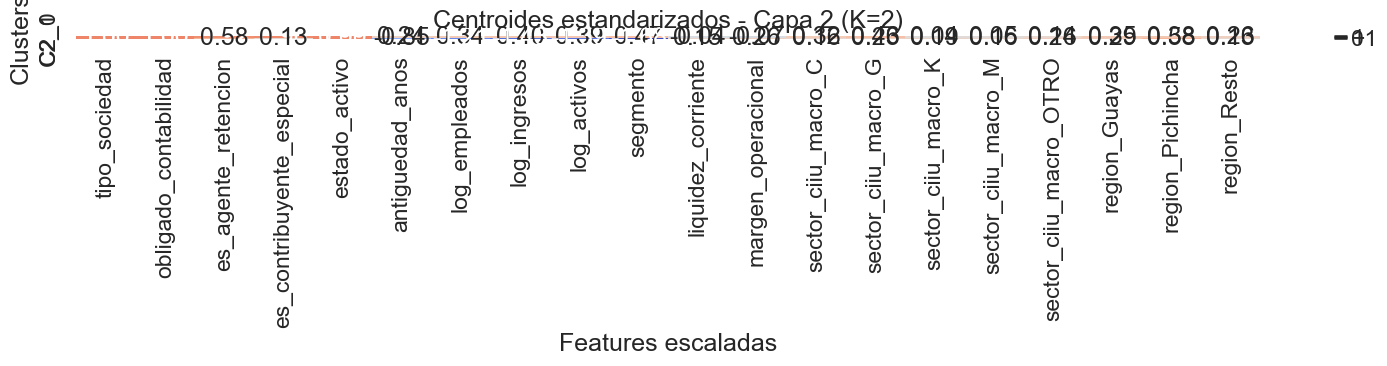

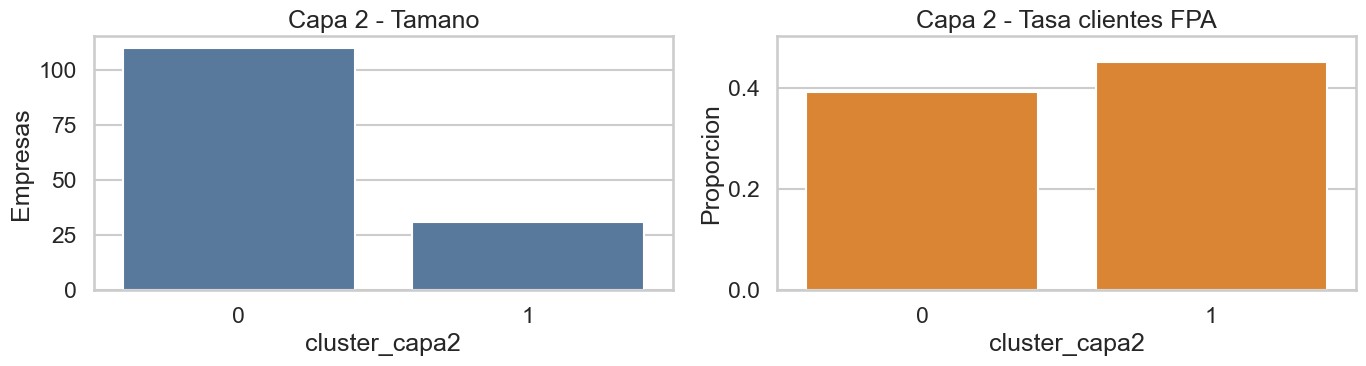

In [13]:
centroides_c2 = pd.DataFrame(modelo_c2.cluster_centers_, columns=matriz_c2.columns)
centroides_c2.index = [f"C2_{cluster}" for cluster in range(K_CAPA2)]
plot_centroid_heatmap(centroides_c2, "Centroides estandarizados - Capa 2 (K=2)")
plot_cluster_validation(resumen_c2, "cluster_capa2", "Capa 2")


In [14]:
modelo_c2_k4 = KMeans(n_clusters=K_CAPA2_SENSIBILIDAD, random_state=RANDOM_STATE, n_init=25)
clusters_c2_k4 = modelo_c2_k4.fit_predict(matriz_c2)

sensibilidad_c2 = features_c2.copy()
sensibilidad_c2["cluster_capa2_k4"] = clusters_c2_k4

resumen_c2_k4 = sensibilidad_c2.groupby("cluster_capa2_k4").agg(
    n=("RUC", "size"),
    tasa_clientes_fpa=("es_cliente_fpa", "mean"),
    mediana_antiguedad_anos=("antiguedad_anos", "median"),
    mediana_log_ingresos=("log_ingresos", "median"),
    mediana_liquidez_corriente=("liquidez_corriente", "median"),
    mediana_margen_operacional=("margen_operacional", "median"),
).reset_index()

clusters_pequenos = (
    sensibilidad_c2["cluster_capa2_k4"].value_counts().loc[lambda s: s <= 2].index.tolist()
)
outliers_c2_k4 = sensibilidad_c2.loc[
    sensibilidad_c2["cluster_capa2_k4"].isin(clusters_pequenos),
    [
        "cluster_capa2_k4",
        "name_norm",
        "RUC",
        "es_cliente_fpa",
        "sector_ciiu_macro",
        "region",
        "anio",
        "log_empleados",
        "log_ingresos",
        "log_activos",
        "segmento",
        "liquidez_corriente",
        "margen_operacional",
    ],
].sort_values(["cluster_capa2_k4", "name_norm"])

display(resumen_c2_k4.round(3))
display(outliers_c2_k4)


,cluster_capa2_k4,n,tasa_clientes_fpa,mediana_antiguedad_anos,mediana_log_ingresos,mediana_liquidez_corriente,mediana_margen_operacional
0,0,71,0.507,46.0,7.886,1.520,-6.51
1,1,15,0.467,8.0,3.884,0.670,0.00
2,2,52,0.250,22.0,6.990,1.465,0.00
3,3,3,0.333,25.0,4.754,20.987,0.00


,cluster_capa2_k4,name_norm,RUC,es_cliente_fpa,sector_ciiu_macro,region,anio,log_empleados,log_ingresos,log_activos,segmento,liquidez_corriente,margen_operacional


## 7. Sesgo de cobertura entre capas

Una pregunta clave para la tesis es si el subconjunto financiero de `Capa 2` representa por igual a todos los perfiles descubiertos en `Capa 1`.


,cluster_capa1,segmento_capa1,n_total,n_con_financieras,cobertura_financiera,tasa_clientes_fpa
0,0,Comercio formal maduro en Pichincha,46,39,0.848,0.435
1,1,Industriales consolidados de alta afinidad FPA,35,22,0.629,0.657
2,2,Comercio formal emergente en Pichincha,60,45,0.750,0.383
3,3,Comercio formal regional en Guayas,40,35,0.875,0.400


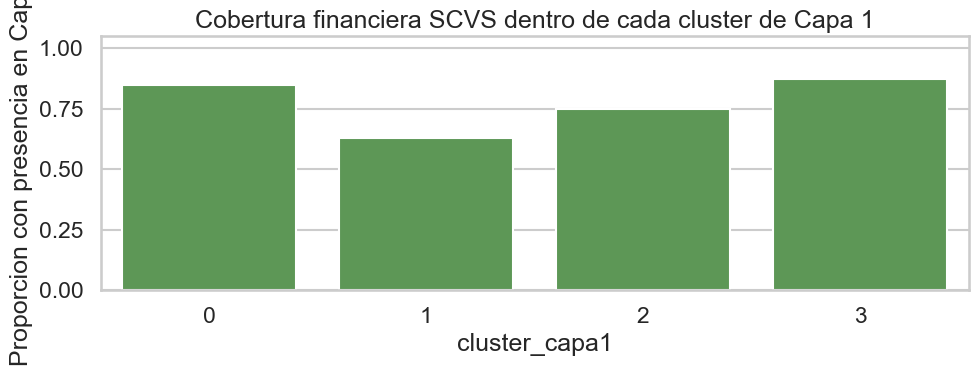

In [15]:
cobertura_c2 = asignaciones_c1.copy()
cobertura_c2["en_capa2"] = cobertura_c2["RUC"].isin(set(asignaciones_c2["RUC"]))
cobertura_c2 = cobertura_c2.groupby(["cluster_capa1", "segmento_capa1"]).agg(
    n_total=("RUC", "size"),
    n_con_financieras=("en_capa2", "sum"),
    cobertura_financiera=("en_capa2", "mean"),
    tasa_clientes_fpa=("es_cliente_fpa", "mean"),
).reset_index().sort_values("cluster_capa1")

display(cobertura_c2.round(3))

plt.figure(figsize=(10, 4))
sns.barplot(data=cobertura_c2, x="cluster_capa1", y="cobertura_financiera", color="#54A24B")
plt.title("Cobertura financiera SCVS dentro de cada cluster de Capa 1")
plt.ylabel("Proporcion con presencia en Capa 2")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()


## 8. Comparacion de robustez entre capas

Se comparan las empresas comunes por RUC usando:

- `ARI` con el mejor `K` de cada capa (`4` vs `2`),
- `ARI` bajo la misma granularidad (`4` vs `4`) como sensibilidad adicional.


In [16]:
comparacion_best = asignaciones_c2.merge(
    asignaciones_c1[["RUC", "cluster_capa1", "segmento_capa1"]],
    on="RUC",
    how="left",
)

asignaciones_c2_k4 = labels_c2.copy()
asignaciones_c2_k4["cluster_capa2_k4"] = clusters_c2_k4

comparacion_same_k = asignaciones_c2_k4.merge(
    asignaciones_c1[["RUC", "cluster_capa1", "segmento_capa1"]],
    on="RUC",
    how="left",
)

ari_best = adjusted_rand_score(comparacion_best["cluster_capa1"], comparacion_best["cluster_capa2"])
ari_same_k = adjusted_rand_score(
    comparacion_same_k["cluster_capa1"],
    comparacion_same_k["cluster_capa2_k4"],
)

print(f"ARI mejor K por capa (Capa1=4 vs Capa2=2): {ari_best:.3f}")
print(f"ARI misma granularidad (Capa1=4 vs Capa2=4): {ari_same_k:.3f}")

tabla_cruce_best = pd.crosstab(
    comparacion_best["cluster_capa1"],
    comparacion_best["cluster_capa2"],
)
tabla_cruce_same_k = pd.crosstab(
    comparacion_same_k["cluster_capa1"],
    comparacion_same_k["cluster_capa2_k4"],
)

display(tabla_cruce_best)
display(tabla_cruce_same_k)


ARI mejor K por capa (Capa1=4 vs Capa2=2): 0.032
ARI misma granularidad (Capa1=4 vs Capa2=4): 0.126


cluster_capa2,0,1
cluster_capa1,,
0,37,2
1,22,0
2,24,21
3,27,8


cluster_capa2_k4,0,1,2,3
cluster_capa1,,,,
0,31,1,6,1
1,19,0,3,0
2,6,12,25,2
3,15,2,18,0


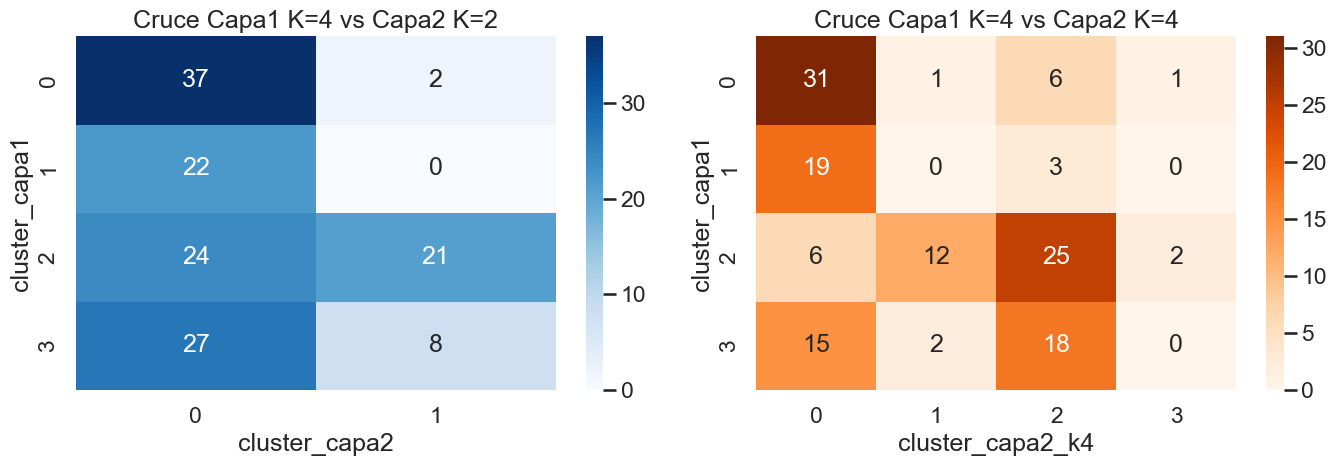

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(tabla_cruce_best, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Cruce Capa1 K=4 vs Capa2 K=2")
axes[0].set_xlabel("cluster_capa2")
axes[0].set_ylabel("cluster_capa1")

sns.heatmap(tabla_cruce_same_k, annot=True, fmt="d", cmap="Oranges", ax=axes[1])
axes[1].set_title("Cruce Capa1 K=4 vs Capa2 K=4")
axes[1].set_xlabel("cluster_capa2_k4")
axes[1].set_ylabel("cluster_capa1")

plt.tight_layout()
plt.show()


## 9. Exportacion de resultados

Se guardan las metricas, las etiquetas de cluster y los resuenes de perfil para ser reutilizados en evaluacion, reporting o scoring posterior.


In [18]:
metricas_kmeans_c1.to_csv(PATH_OUT / "metricas_kmeans_capa1.csv", index=False)
metricas_kmeans_c2.to_csv(PATH_OUT / "metricas_kmeans_capa2.csv", index=False)
metricas_ward_c1.to_csv(PATH_OUT / "metricas_ward_capa1.csv", index=False)
metricas_ward_c2.to_csv(PATH_OUT / "metricas_ward_capa2.csv", index=False)

asignaciones_c1.to_csv(PATH_OUT / "clusters_capa1.csv", index=False)
asignaciones_c2.to_csv(PATH_OUT / "clusters_capa2.csv", index=False)
asignaciones_c2_k4.to_csv(PATH_OUT / "clusters_capa2_k4_sensibilidad.csv", index=False)

resumen_c1.to_csv(PATH_OUT / "perfil_clusters_capa1.csv", index=False)
resumen_c2.to_csv(PATH_OUT / "perfil_clusters_capa2.csv", index=False)
resumen_c2_k4.to_csv(PATH_OUT / "perfil_clusters_capa2_k4.csv", index=False)
cobertura_c2.to_csv(PATH_OUT / "cobertura_financiera_por_cluster_capa1.csv", index=False)
comparacion_best.to_csv(PATH_OUT / "comparacion_capas_best_k.csv", index=False)
comparacion_same_k.to_csv(PATH_OUT / "comparacion_capas_same_k.csv", index=False)

archivos_generados = sorted([path.name for path in PATH_OUT.glob("*.csv")])
pd.DataFrame({"archivo_generado": archivos_generados})


,archivo_generado
0,clusters_capa1.csv
1,clusters_capa2.csv
2,clusters_capa2_k4_sensibilidad.csv
3,cobertura_financiera_por_cluster_capa1.csv
4,comparacion_capas_best_k.csv
5,comparacion_capas_same_k.csv
6,metricas_kmeans_capa1.csv
7,metricas_kmeans_capa2.csv
8,metricas_ward_capa1.csv
9,metricas_ward_capa2.csv


## 10. Conclusiones ejecutivas

1. `Capa 1` con `K=4` entrega una segmentacion interpretable y balanceada para el modelo principal de la tesis.
2. `Capa 2` con `K=2` es la solucion estable cuando se incorporan variables financieras; con `K>=3` aparecen clusters diminutos inducidos por outliers.
3. La concordancia entre capas es parcial (`ARI` moderado-bajo), lo que sugiere que la firma financiera agrega estructura nueva y no solo refina la segmentacion SRI.
4. El sesgo de cobertura es material: el cluster menos formalizado de `Capa 1` no tiene presencia financiera en `Capa 2`, por lo que el enriquecimiento SCVS no representa por igual a todos los perfiles del universo comercial.
